# <font color=blue> 기계학습 기초 4장: 선형예측 (Linear Prediction) </font>
###  Machine Learning and Bioinformatics (MLBI) Lab @ DKU, 2020.07.04 <br>

## 학습 목표
- 시계열 데이터를 과거 값으로부터 다음 값을 예측하는 supervised learning 문제로 바꾼다.
- Toeplitz 행렬을 이용해 sequence 입력을 구성한다.
- 선형회귀 기반 예측 결과를 시각화하고 오차를 해석한다.

## 사용할 데이터
- `load_data('time-series')`: 예제 시계열 데이터

## 직접 바꿔볼 것
- 예측에 사용할 과거 시점 개수 `p`
- 예측할 미래 시점 개수 `q`
- perturbation 크기


In [1]:
# !pip install anndata
# !pip install mlbi-lab --upgrade

In [2]:
import math, os
import numpy as np
import pandas as pd
import sklearn.linear_model as lm
import sklearn.svm as svm
import sklearn.model_selection as mod_sel
import sklearn.metrics as met
import matplotlib.pyplot as plt
import seaborn as sns

from mlbi.datasets import load_data, load_anndata

from scipy.stats import pearsonr
from numpy.random import randn
from scipy.linalg import toeplitz

/mnt/HDD2/Google_drive/PyPI_Git_Publish/pub_mlbi_lab/src/mlbi/datasets.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. 회귀분석을 위한 전처리

1. 전처리 - csv 파일 불러와서 열기
2. 특징 벡터와 목표값 설정
3. regressor 정의

#### (1) 전처리 - csv 파일 불러와서 열기

In [3]:
load_data()

You can select one of:
  cancerseek
  ccle-ctrpv2
  heart_failure
  hotel_bookings
  house_price
  labor_force
  metabric
  scores
  tcga-brca
  time-series
  time-series2


In [4]:
## (1) load time series data
df = load_data('time-series')
df

,TS1,TS2
0,3.343,3.365
1,3.566,3.714
2,3.985,4.243
3,4.383,4.522
4,4.524,4.327
...,...,...
1495,3.763,3.776
1496,4.009,3.800
1497,4.365,3.844
1498,4.603,4.129


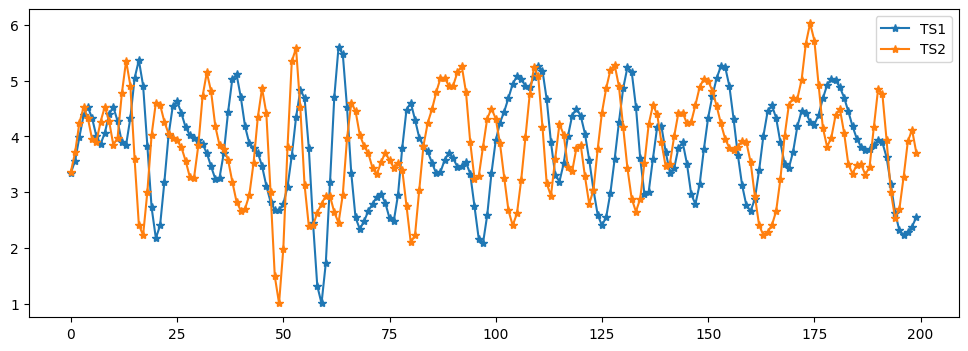

In [5]:
plt.figure(figsize = (12,4))
plt.plot(df.iloc[:200], '*-')
plt.legend(df.columns.values)
plt.show()

In [6]:
df.shape

(1500, 2)

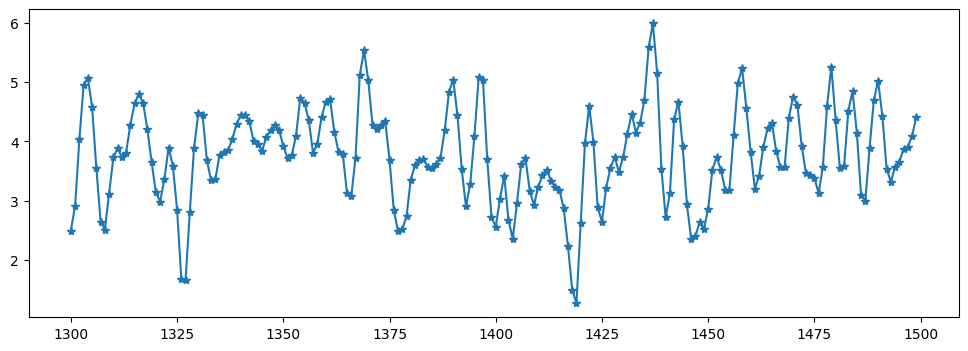

In [7]:
## 사용할 Time series 의 선택 및 Perturbation 추가
target = 'TS2'
perturbation = 0.1
N_to_plot = 200

t = df.index.values
s = np.array(df[target])
s = s + randn(len(s))*(s.std()*perturbation)

plt.figure(figsize = (12,4))
plt.plot(t[-N_to_plot:], s[-N_to_plot:], '*-')
plt.show()

#### (2) 특징 벡터와 목표값 설정

In [8]:
# 예측 차수
p = 4 # 예측 차수
q = 1 # 미래의 값 몇개를 예측할건지

c = np.flip(s[:(p+q)])
r = s[(p+q-1):]
S = np.fliplr(toeplitz(r, c))

In [9]:
S.shape

(1496, 5)

In [10]:
X = S[:,:p]
y = S[:,p:]

test_size = 0.25
N_samples = X.shape[0]

N_train = int(N_samples*(1-test_size))
N_test = int(N_samples*test_size)

y_test = y[-N_test:]
X_test = X[-N_test:,:]

y_train = y[:N_train]
X_train = X[:N_train,:]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1122, 4), (1122, 1), (374, 4), (374, 1))

In [11]:
X, y

(array([[3.45212046, 3.72342789, 4.2508438 , 4.56062461],
        [3.72342789, 4.2508438 , 4.56062461, 4.23402761],
        [4.2508438 , 4.56062461, 4.23402761, 3.96161316],
        ...,
        [3.31330975, 3.5703354 , 3.65143879, 3.87938759],
        [3.5703354 , 3.65143879, 3.87938759, 3.90938282],
        [3.65143879, 3.87938759, 3.90938282, 4.09230796]]),
 array([[4.23402761],
        [3.96161316],
        [3.87484332],
        ...,
        [3.90938282],
        [4.09230796],
        [4.41613186]]))

In [12]:
N_samples, N_train, N_test

(1496, 1122, 374)

학습 데이터와 목표 값 확인

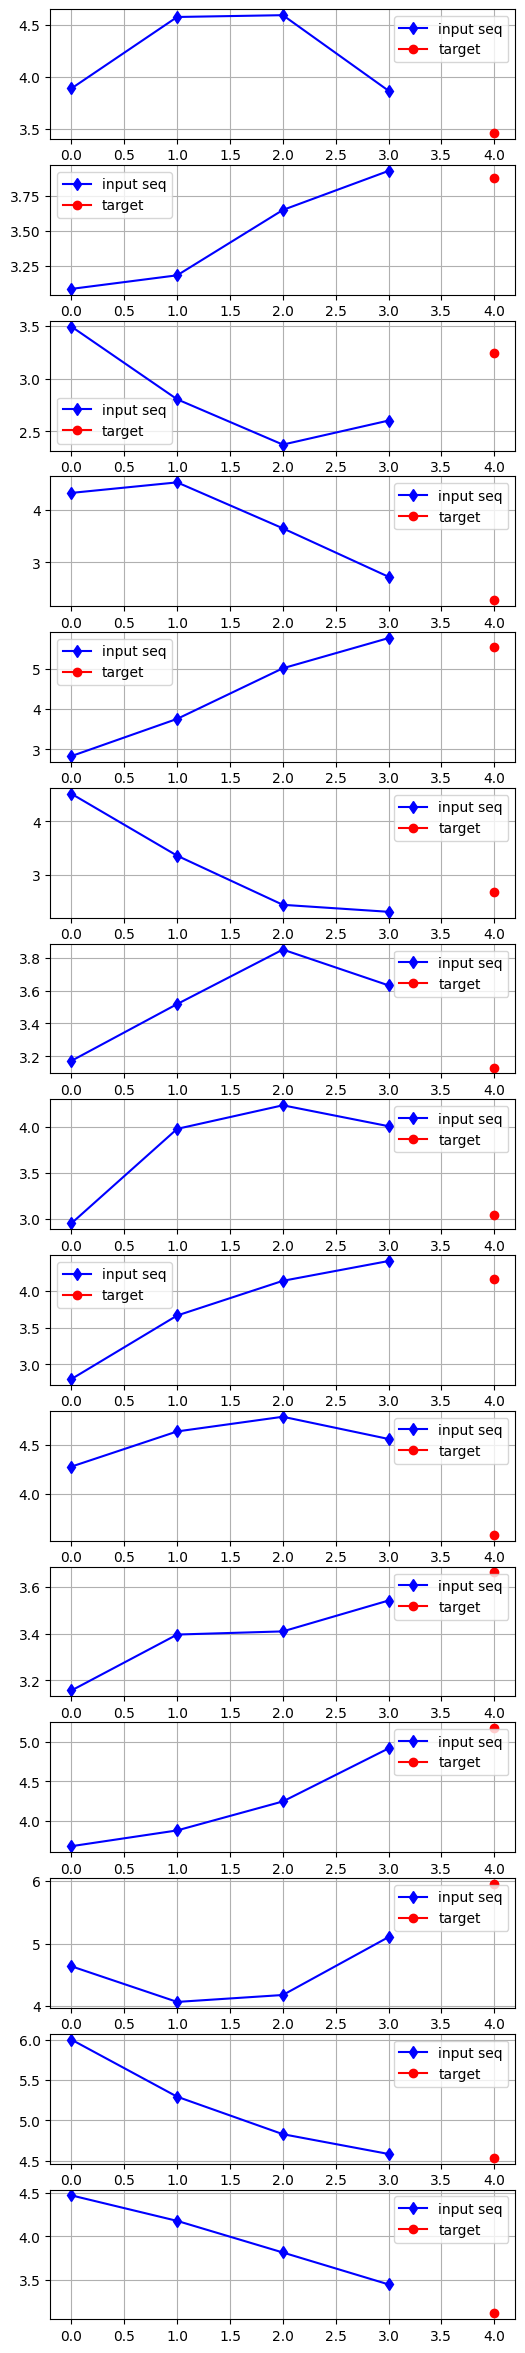

In [13]:
Nplt = 15
step = 5
plt.figure(figsize = (6, 2*Nplt))
for i in range(Nplt):
    plt.subplot(Nplt,1,i+1)
    plt.plot(np.arange(p), X_test[i*step,:], 'bd-', label="input seq")
    plt.plot(np.arange(q)+p, y_test[i*step], 'ro-', label="target")
    plt.legend()
    plt.grid()
plt.show()

In [14]:
X

array([[3.45212046, 3.72342789, 4.2508438 , 4.56062461],
       [3.72342789, 4.2508438 , 4.56062461, 4.23402761],
       [4.2508438 , 4.56062461, 4.23402761, 3.96161316],
       ...,
       [3.31330975, 3.5703354 , 3.65143879, 3.87938759],
       [3.5703354 , 3.65143879, 3.87938759, 3.90938282],
       [3.65143879, 3.87938759, 3.90938282, 4.09230796]])

In [15]:
y

array([[4.23402761],
       [3.96161316],
       [3.87484332],
       ...,
       [3.90938282],
       [4.09230796],
       [4.41613186]])

## Model to use: Linear regression model
__Model description:__ https://scikit-learn.org/stable/modules/linear_model.html

#### __Model:__&nbsp;     $ \hat{y_i} = {\bf x} ^T_i {\boldsymbol{\theta}} + \theta_0 $ &nbsp;&nbsp;&nbsp;  
#### __Cost to minimize:__ &nbsp;     $ \min_{{\boldsymbol{\theta}},\theta_0} \sum^{n}_{i=1} \left( {\bf x} ^T_i {\boldsymbol{\theta}} + \theta_0  - y_i \right)^2 $

__Function description:__ https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html


#### 선형회귀 모형

<div style="display:flex; gap:24px; align-items:flex-start;">
  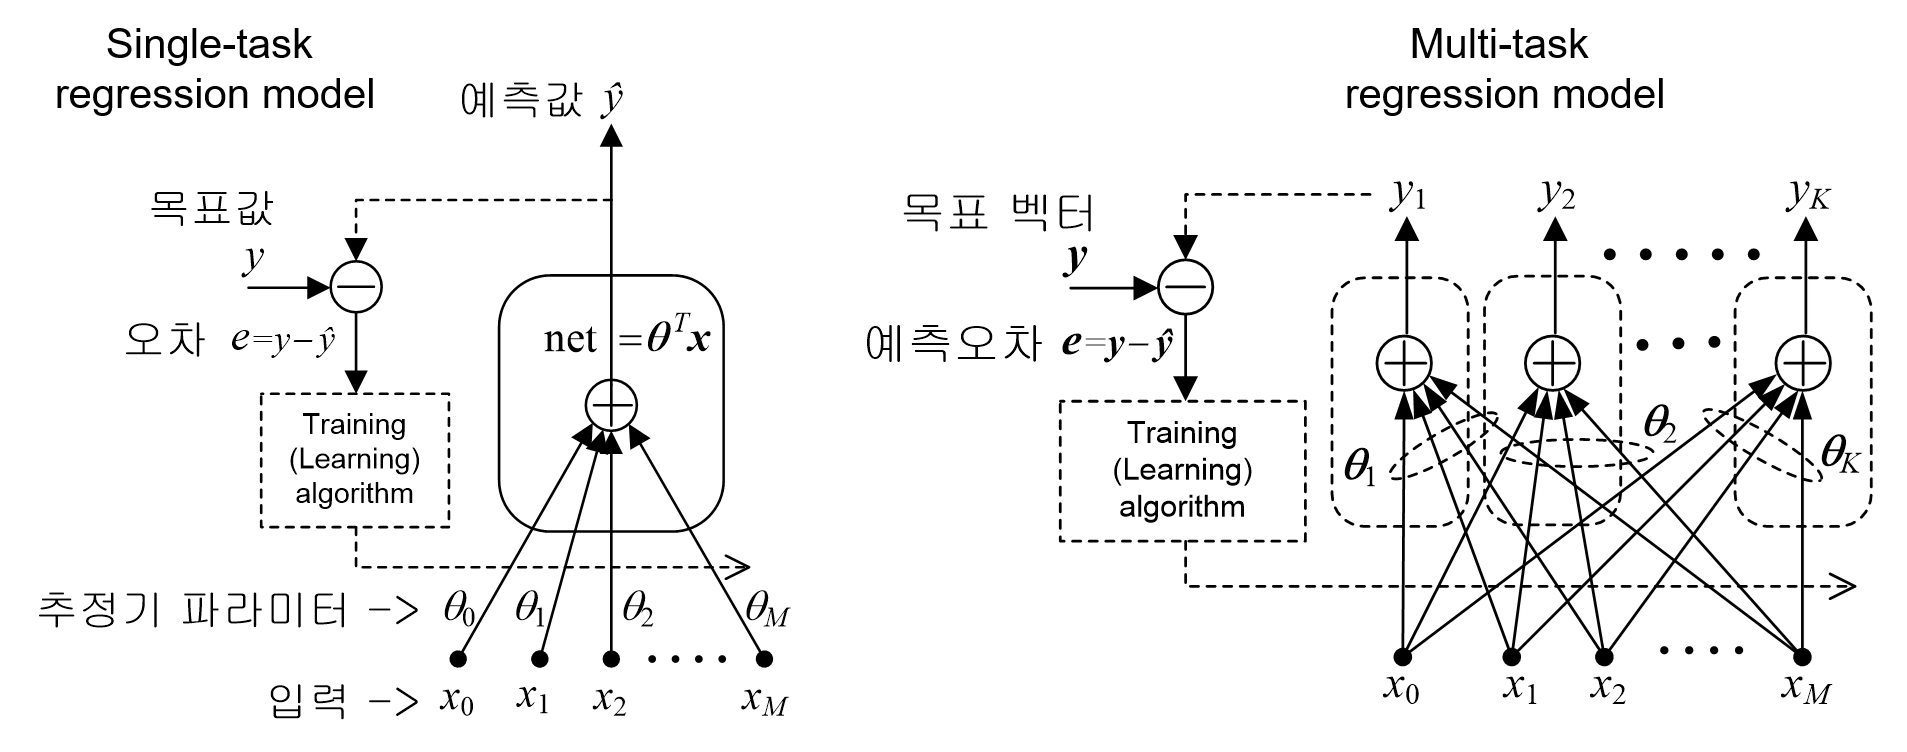  
</div>


#### (3) regressor 정의
#### Set linear regressor and its parameters to use for regression

In [16]:
#########################################################
## (3) Set linear regressor and its parameters to use

## Plain Linear Model (Ordinary Least Squares)
regressor = lm.LinearRegression( )

param_default = regressor.get_params()
print('Default hyper parameters: ', param_default)

Default hyper parameters:  {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}


#### Other regressors available online: https://scikit-learn.org/0.21/supervised_learning.html#supervised-learning

## 2. 기본 학습 절차

#### (1) 데이터를 학습데이터와 테스트 데이터로 분리

#### (2) 학습 수행(fit)

#### (3) 테스트 수행 (predict)

#### (4) 성능/결과 확인

#### 학습 절차

<div style="display:flex; gap:24px; align-items:flex-start;">
  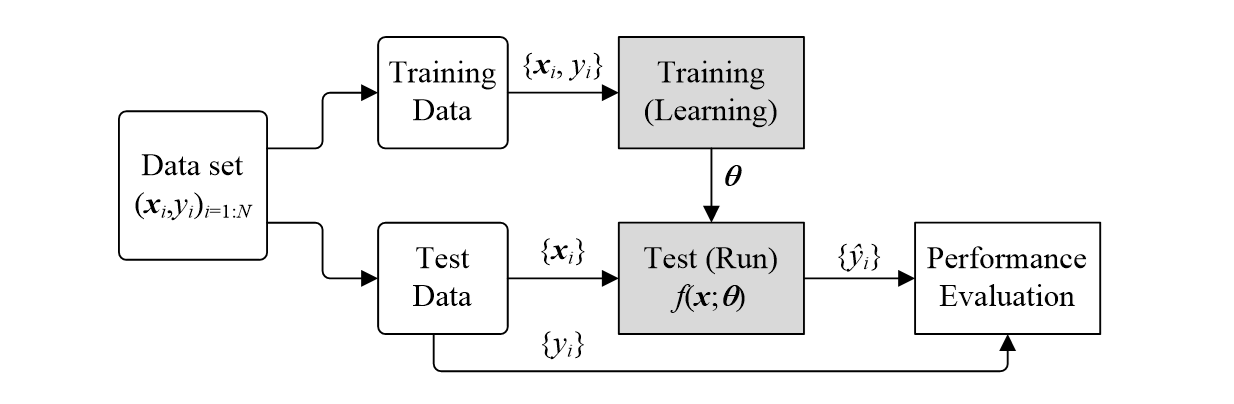
</div>
  

In [17]:
y_train.shape, X_train.shape

((1122, 1), (1122, 4))

In [18]:
## (2) Fit model to the data, X_train and y_train
regressor.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
regressor.intercept_

array([0.84117847])

In [20]:
regressor.coef_.shape

(1, 4)

In [21]:
regressor.coef_.shape, regressor.intercept_.shape

((1, 4), (1,))

In [22]:
## (3) Performance test
y_pred = regressor.predict(X_test)
y_pred_train = regressor.predict(X_train)

In [23]:
y_test

array([[3.45738948],
       [3.0878945 ],
       [3.18439535],
       [3.64852542],
       [3.9261607 ],
       [3.87853712],
       [3.49235644],
       [2.80389341],
       [2.37474524],
       [2.60248825],
       [3.23896781],
       [4.32984908],
       [4.53126905],
       [3.65188346],
       [2.7242809 ],
       [2.27345876],
       [2.83557375],
       [3.75561521],
       [5.00684077],
       [5.75319281],
       [5.53699173],
       [4.50912946],
       [3.36191434],
       [2.45162588],
       [2.32196933],
       [2.6853242 ],
       [3.17277207],
       [3.51767526],
       [3.84892723],
       [3.63133873],
       [3.1318122 ],
       [2.95014053],
       [3.975105  ],
       [4.23117174],
       [4.00409818],
       [3.0433146 ],
       [2.80277725],
       [3.66632115],
       [4.13770831],
       [4.40704579],
       [4.16479913],
       [4.27814224],
       [4.63176091],
       [4.7794392 ],
       [4.55592767],
       [3.59270698],
       [3.1567734 ],
       [3.396

In [24]:
## (4) Check Performance
# mse = ((y_test - y_pred)**2).mean()
mse = met.mean_squared_error(y_test, y_pred)
mse_norm = mse/y_test.var()

# mse_train = ((y_train - y_pred_train)**2).mean()
mse_train = met.mean_squared_error(y_train, y_pred_train)
mse_norm_train = mse_train/y_train.var()

print( "Normalized.MSE = %f, %f" % (round(mse_norm,8), round(mse_norm_train,8)) )


Normalized.MSE = 0.149105, 0.136993


In [25]:
mse_norm

0.14910490670416807

In [26]:
y_pred.shape, y_test.shape

((374, 1), (374, 1))

In [27]:
## (5) Check Performance
for i in range(y_test.shape[1]):
    mse = met.mean_squared_error(y_test[:,i], y_pred[:,i])
    mse_norm = mse/y_test[:,i].var()

    # mse_train = ((y_train - y_pred_train)**2).mean()
    mse_train = met.mean_squared_error(y_train[:,i], y_pred_train[:,i])
    mse_norm_train = mse_train/y_train[:,i].var()

    print( "Normalized.MSE = %f, %f" % (round(mse_norm,8), round(mse_norm_train,8)) )

Normalized.MSE = 0.149105, 0.136993


#### Scatter plot 확인

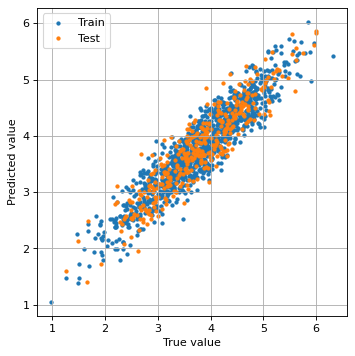

In [28]:
## (7) Scatter plot
plt.figure(num=None, figsize=(5, 5), dpi=80)

k = 0
plt.scatter(y_train[:,k],y_pred_train[:,k], label = 'Train', s = 8)
plt.scatter(y_test[:,k],y_pred[:,k], label = 'Test', s = 8)
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.grid()
plt.legend()
plt.show()


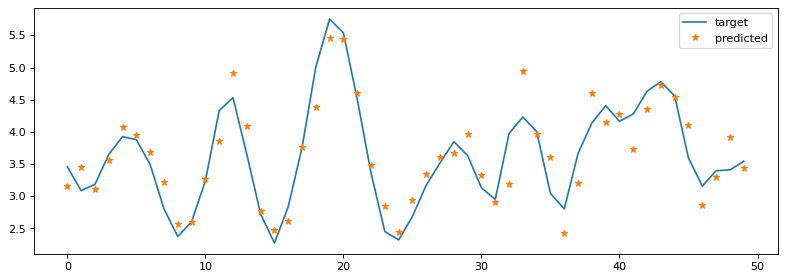

In [29]:
plt.figure(num=None, figsize=(12, 4), dpi=80)

plt.plot(y_test[:50], label="target")
plt.plot(y_pred[:50], '*', label="predicted")
plt.legend()
plt.show()


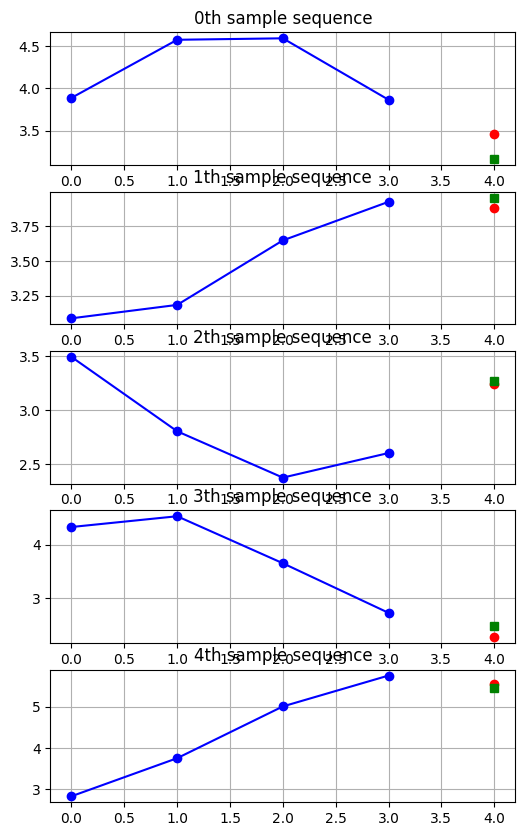

In [30]:
Nplt = 5
step = 5
plt.figure(figsize = (6, 2*Nplt))
for i in range(Nplt):
    plt.subplot(Nplt,1,i+1)
    plt.plot(np.arange(p), X_test[i*step,:], 'bo-', label="input seq")
    plt.plot(np.arange(y_test.shape[1])+p, y_test[i*step], 'ro', label="target")
    plt.plot(np.arange(y_test.shape[1])+p, y_pred[i*step], 'gs', label="predicted")
    # plt.legend()
    plt.title(str(i) + "th sample sequence")
    plt.grid()
plt.show()


 ## 3. 학습을 통해 획득한 파라미터와 연립방정식 해의 비교
 #### a. 학습을 통해 획득한 최적 파라미터 파라미터 확인

In [31]:
print( "theta_0 (intercept) = " + str(regressor.intercept_) )
print( "theta[1~M] = " + str(regressor.coef_) )
print( "theta_tilde = " + str( [regressor.intercept_[0]] + list(regressor.coef_[0]) ))

theta_0 (intercept) = [0.84117847]
theta[1~M] = [[ 0.04596497  0.34981032 -1.28607955  1.66870282]]
theta_tilde = [0.8411784716409252, 0.045964972362670616, 0.349810319419246, -1.2860795510438132, 1.6687028156724608]


 #### b 연립방정식의 해

In [32]:
X_mat = X_train # 데이터 프레임을 행렬로 변환
y_vec = y_train
X_tilde = np.c_[np.ones([X_mat.shape[0],1]), X_mat]  # 앞에 1을 추가하여 첨가행렬 구성

Rxx = X_tilde.transpose().dot(X_tilde)/X_mat.shape[0] # 자기 상관행렬
rxy = X_tilde.transpose().dot(y_vec)/X_mat.shape[0] # 상호 상관벡터
theta_tilde = np.linalg.inv(Rxx).dot(rxy) # 최적 파라미터 Theta_tilde
print("theta_tilde = " + str(np.array(theta_tilde[:,0])) )

theta_tilde = [ 0.84117847  0.04596497  0.34981032 -1.28607955  1.66870282]


## 4. 교차 검증

#### sklearn.model_selection 모듈의 .cross_val_score 사용

#### 교차검증 절차 모식도

<div style="display:flex; gap:24px; align-items:flex-start;">
  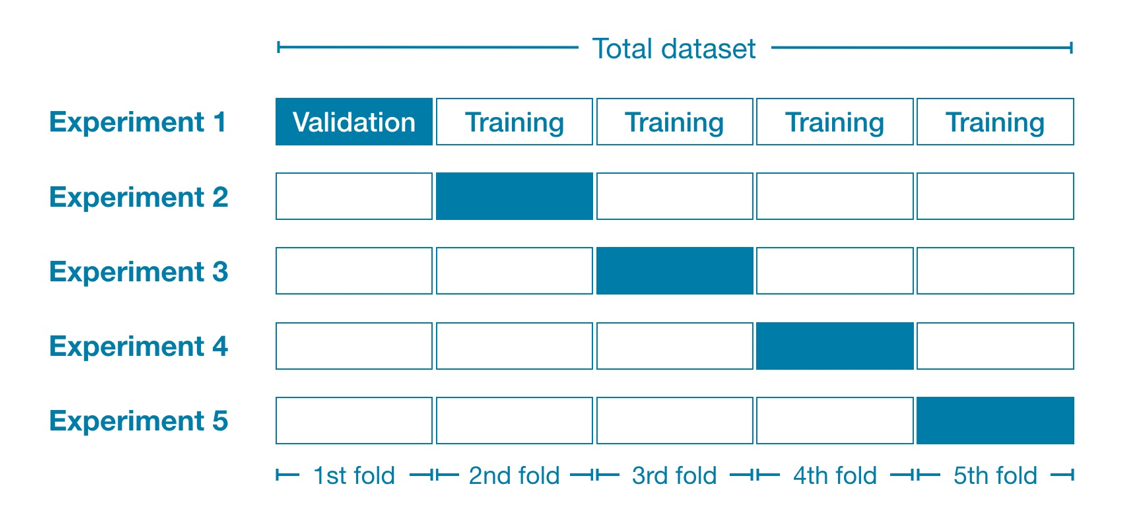  
</div>


In [33]:
#########################################################
## 3. Regression example: Cross-validation

## Set parameters for cross-validation
NCV = 10
## Performance test
cv_scores = mod_sel.cross_val_score(regressor, X, y, \
                                    scoring='neg_mean_squared_error', cv=NCV, n_jobs = 4)

score = -cv_scores.mean()/y.var() ## Normalized MSE
print( "Normalized.MSE (CV) = " + str(round(score,4)) )

Normalized.MSE (CV) = 0.1406


/home/syoon/Programs/anaconda3/envs/py312/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/syoon/Programs/anaconda3/envs/py312/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/syoon/Programs/anaconda3/envs/py312/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11

In [34]:
cv_scores.shape

(10,)

In [35]:
## Performance test
y_pred_cv = mod_sel.cross_val_predict(regressor, X, y, \
                                      cv=NCV, n_jobs = 4)

In [36]:
y_pred_cv.shape

(1496, 1)

In [37]:
# mse = met.mean_squared_error(y, y_pred_cv)
mse = ((y - y_pred_cv)**2).mean(axis = 0)
mse_norm = mse/y.var(axis = 0)

mse_norm

array([0.14065385])

In [38]:
mse = ((y - y_pred_cv)**2).mean(axis = 0)
mse

array([0.09583507])

## Homework

시계열 데이터 TS1에 대해 다음을 수행하라.
1. q = 1로 놓고 p = 4,8,16,32,64... 에 대해 예측 성능을 평가하고 이를 적당히 요약해 보아라.
2. 3개 시점에서의 값을 동시에 예측하는 q = 3인 경우를 고려해보자. 즉, $x_{t+j} = \theta_0 + \theta_1 x_{t-1} + ... + \theta_p x_{t-p}$ 여기서 $j=0,1,2$. $j$가 각각 0,1,2일 때에 대한 예측성능을 평가하고 이를 적당히 요약해 보아라.
3. 이상의 결과를 요약하여 보고서를 제출하라. 보고서의 내용은 다음을 포함해야 한다.
   - 서론: 실험에 대한 간략한 요약 - 0.5페이지
   - 실험 방법 및 절차 - 1페이지
   - 실험 결과 요약 - 2페이지
   - 실험 결과에 대한 고찰 - 0.5페이지

- pdf로 제출
- 그림은 각 페이지분량의 50%를 넘지 않아야 함
- 여백: 상하좌우 2cm
- 폰트 크기: 10
- 줄간격: MS Word 1줄. HWP: 110%
- e-campus에 제출
